In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Lab2_titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Objective: Apply preprocessing techniques to raw data.
Topics: Missing values, normalization, binning, encoding.
Tasks:
§ Load a dataset and handle missing values.
§ Dealing with categorical data: Label encoding and one-hot encoding of categorical
variables
§ Scaling the features: Perform min-max normalisation and Z-score standardisation.
§ Similarity and Dissimilarity Measures:
1. Pearson’s Correlation
2. Cosine Similarity
3. Jaccard Similarity
4. Euclidean Distance


## 1. Load Dataset and Explore

In [23]:
# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (891, 12)

First few rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0     

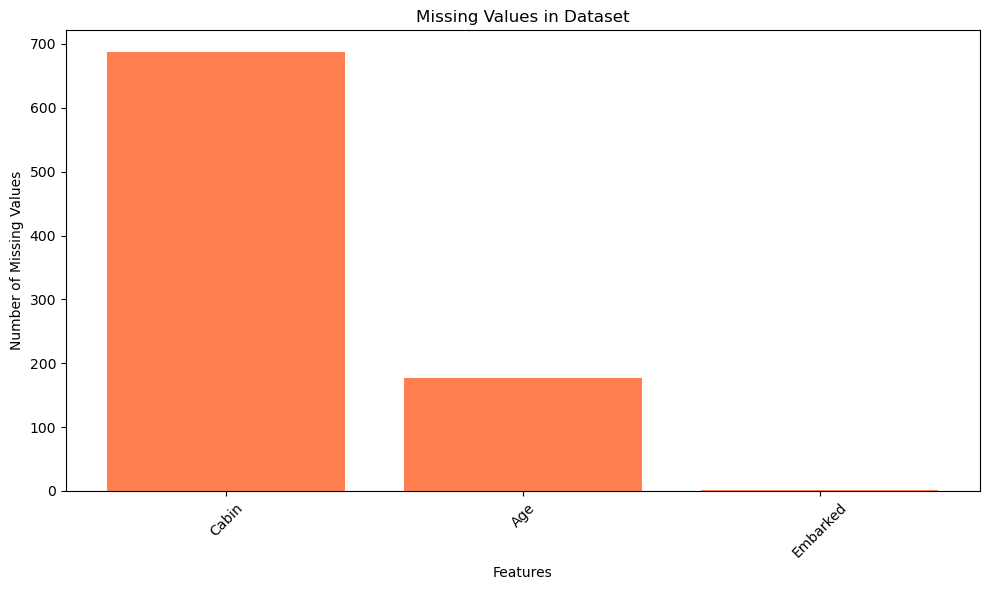

In [4]:
# Visualize missing values
plt.figure(figsize=(10, 6))
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
plt.bar(missing_data.index, missing_data.values, color='coral')
plt.xlabel('Features')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values in Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Handle Missing Values

In [5]:
# Create a copy of the dataframe for preprocessing
df_clean = df.copy()

# Handle missing values
# For Age: Fill with median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# For Cabin: Fill with 'Unknown' (high missing rate)
df_clean['Cabin'].fillna('Unknown', inplace=True)

# For Embarked: Fill with mode (most frequent value)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# For Fare: Fill with median (if any missing)
if df_clean['Fare'].isnull().sum() > 0:
    df_clean['Fare'].fillna(df_clean['Fare'].median(), inplace=True)

print("Missing values after handling:")
print(df_clean.isnull().sum())
print("\nDataset shape:", df_clean.shape)

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Dataset shape: (891, 12)


/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_34028/2311284495.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_34028/2311284495.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setti

## 3. Dealing with Categorical Data

In [6]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for binary and ordinal categorical variables
print("=== Label Encoding ===\n")

# Create a copy for label encoding
df_label = df_clean.copy()

# Label Encoding for 'Sex' (binary: male/female)
le_sex = LabelEncoder()
df_label['Sex_Encoded'] = le_sex.fit_transform(df_label['Sex'])
print("Sex - Label Encoding:")
print(df_label[['Sex', 'Sex_Encoded']].drop_duplicates().sort_values('Sex'))

# Label Encoding for 'Embarked'
le_embarked = LabelEncoder()
df_label['Embarked_Encoded'] = le_embarked.fit_transform(df_label['Embarked'])
print("\nEmbarked - Label Encoding:")
print(df_label[['Embarked', 'Embarked_Encoded']].drop_duplicates().sort_values('Embarked'))

print("\nLabel Encoded DataFrame (first 5 rows):")
print(df_label[['Sex', 'Sex_Encoded', 'Embarked', 'Embarked_Encoded']].head())

=== Label Encoding ===

Sex - Label Encoding:
      Sex  Sex_Encoded
1  female            0
0    male            1

Embarked - Label Encoding:
  Embarked  Embarked_Encoded
1        C                 0
5        Q                 1
0        S                 2

Label Encoded DataFrame (first 5 rows):
      Sex  Sex_Encoded Embarked  Embarked_Encoded
0    male            1        S                 2
1  female            0        C                 0
2  female            0        S                 2
3  female            0        S                 2
4    male            1        S                 2


In [7]:
# One-Hot Encoding for nominal categorical variables
print("=== One-Hot Encoding ===\n")

# Create a copy for one-hot encoding
df_onehot = df_clean.copy()

# One-Hot Encoding for 'Embarked'
embarked_dummies = pd.get_dummies(df_onehot['Embarked'], prefix='Embarked')
df_onehot = pd.concat([df_onehot, embarked_dummies], axis=1)

# One-Hot Encoding for 'Sex'
sex_dummies = pd.get_dummies(df_onehot['Sex'], prefix='Sex')
df_onehot = pd.concat([df_onehot, sex_dummies], axis=1)

# One-Hot Encoding for 'Pclass'
pclass_dummies = pd.get_dummies(df_onehot['Pclass'], prefix='Pclass')
df_onehot = pd.concat([df_onehot, pclass_dummies], axis=1)

print("One-Hot Encoded Columns:")
print(df_onehot[['Embarked_C', 'Embarked_Q', 'Embarked_S', 
                 'Sex_female', 'Sex_male', 
                 'Pclass_1', 'Pclass_2', 'Pclass_3']].head(10))

print("\nDataFrame shape after One-Hot Encoding:", df_onehot.shape)

=== One-Hot Encoding ===

One-Hot Encoded Columns:
   Embarked_C  Embarked_Q  Embarked_S  Sex_female  Sex_male  Pclass_1  \
0       False       False        True       False      True     False   
1        True       False       False        True     False      True   
2       False       False        True        True     False     False   
3       False       False        True        True     False      True   
4       False       False        True       False      True     False   
5       False        True       False       False      True     False   
6       False       False        True       False      True      True   
7       False       False        True       False      True     False   
8       False       False        True        True     False     False   
9        True       False       False        True     False     False   

   Pclass_2  Pclass_3  
0     False      True  
1     False     False  
2     False      True  
3     False     False  
4     False      True  
5

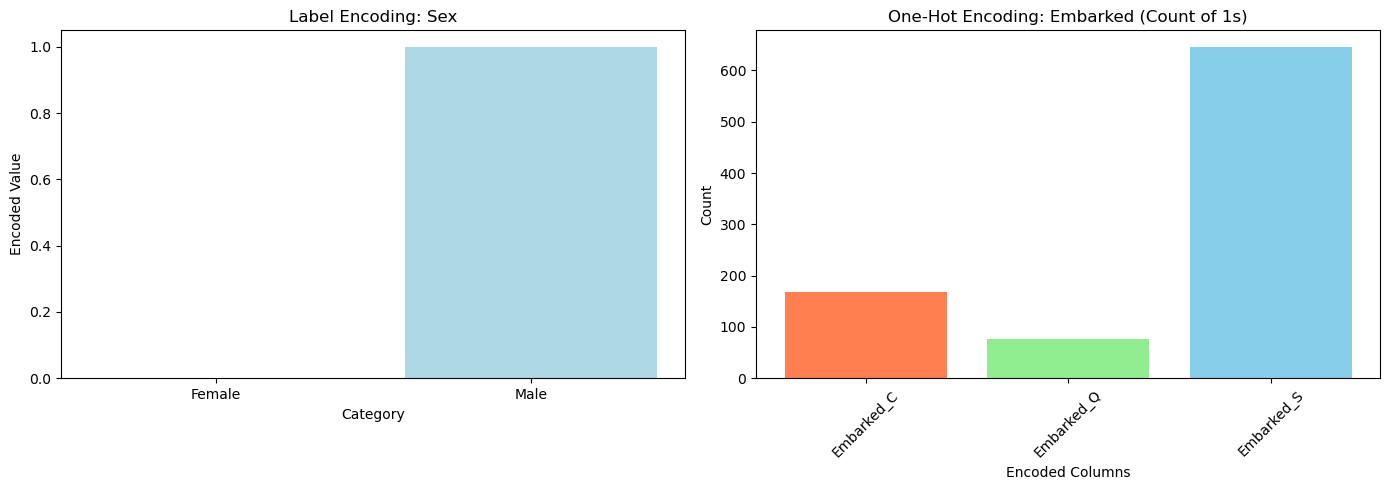

In [8]:
# Visualize encoding comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label Encoding visualization
axes[0].bar(['Female', 'Male'], df_label.groupby('Sex')['Sex_Encoded'].first().values, color=['pink', 'lightblue'])
axes[0].set_title('Label Encoding: Sex')
axes[0].set_ylabel('Encoded Value')
axes[0].set_xlabel('Category')

# One-Hot Encoding visualization
embarked_counts = df_onehot[['Embarked_C', 'Embarked_Q', 'Embarked_S']].sum()
axes[1].bar(embarked_counts.index, embarked_counts.values, color=['coral', 'lightgreen', 'skyblue'])
axes[1].set_title('One-Hot Encoding: Embarked (Count of 1s)')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Encoded Columns')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Scaling the Features

In [9]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Select numerical features for scaling
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']

# Create a dataframe with only numerical features
df_numeric = df_clean[numerical_features].copy()

print("Original Data Statistics:")
print(df_numeric.describe())
print("\n" + "="*50 + "\n")

Original Data Statistics:
              Age        Fare       SibSp       Parch
count  891.000000  891.000000  891.000000  891.000000
mean    29.361582   32.204208    0.523008    0.381594
std     13.019697   49.693429    1.102743    0.806057
min      0.420000    0.000000    0.000000    0.000000
25%     22.000000    7.910400    0.000000    0.000000
50%     28.000000   14.454200    0.000000    0.000000
75%     35.000000   31.000000    1.000000    0.000000
max     80.000000  512.329200    8.000000    6.000000




In [10]:
# Min-Max Normalization (scaling to [0, 1])
print("=== Min-Max Normalization ===")
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_numeric),
    columns=[f'{col}_MinMax' for col in numerical_features],
    index=df_numeric.index
)

print("\nMin-Max Normalized Data (first 10 rows):")
print(df_minmax.head(10))
print("\nMin-Max Normalized Data Statistics:")
print(df_minmax.describe())

=== Min-Max Normalization ===

Min-Max Normalized Data (first 10 rows):
   Age_MinMax  Fare_MinMax  SibSp_MinMax  Parch_MinMax
0    0.271174     0.014151         0.125      0.000000
1    0.472229     0.139136         0.125      0.000000
2    0.321438     0.015469         0.000      0.000000
3    0.434531     0.103644         0.125      0.000000
4    0.434531     0.015713         0.000      0.000000
5    0.346569     0.016510         0.000      0.000000
6    0.673285     0.101229         0.000      0.000000
7    0.019854     0.041136         0.375      0.166667
8    0.334004     0.021731         0.000      0.333333
9    0.170646     0.058694         0.125      0.000000

Min-Max Normalized Data Statistics:
       Age_MinMax  Fare_MinMax  SibSp_MinMax  Parch_MinMax
count  891.000000   891.000000    891.000000    891.000000
mean     0.363679     0.062858      0.065376      0.063599
std      0.163605     0.096995      0.137843      0.134343
min      0.000000     0.000000      0.000000      

In [11]:
# Z-Score Standardization (mean=0, std=1)
print("\n" + "="*50)
print("=== Z-Score Standardization ===")
standard_scaler = StandardScaler()
df_zscore = pd.DataFrame(
    standard_scaler.fit_transform(df_numeric),
    columns=[f'{col}_ZScore' for col in numerical_features],
    index=df_numeric.index
)

print("\nZ-Score Standardized Data (first 10 rows):")
print(df_zscore.head(10))
print("\nZ-Score Standardized Data Statistics:")
print(df_zscore.describe())


=== Z-Score Standardization ===

Z-Score Standardized Data (first 10 rows):
   Age_ZScore  Fare_ZScore  SibSp_ZScore  Parch_ZScore
0   -0.565736    -0.502445      0.432793     -0.473674
1    0.663861     0.786845      0.432793     -0.473674
2   -0.258337    -0.488854     -0.474545     -0.473674
3    0.433312     0.420730      0.432793     -0.473674
4    0.433312    -0.486337     -0.474545     -0.473674
5   -0.104637    -0.478116     -0.474545     -0.473674
6    1.893459     0.395814     -0.474545     -0.473674
7   -2.102733    -0.224083      2.247470      0.767630
8   -0.181487    -0.424256     -0.474545      2.008933
9   -1.180535    -0.042956      0.432793     -0.473674

Z-Score Standardized Data Statistics:
         Age_ZScore   Fare_ZScore  SibSp_ZScore  Parch_ZScore
count  8.910000e+02  8.910000e+02  8.910000e+02  8.910000e+02
mean   2.272780e-16  3.987333e-18  4.386066e-17  5.382900e-17
std    1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00
min   -2.224156e+00 -6.484217e-

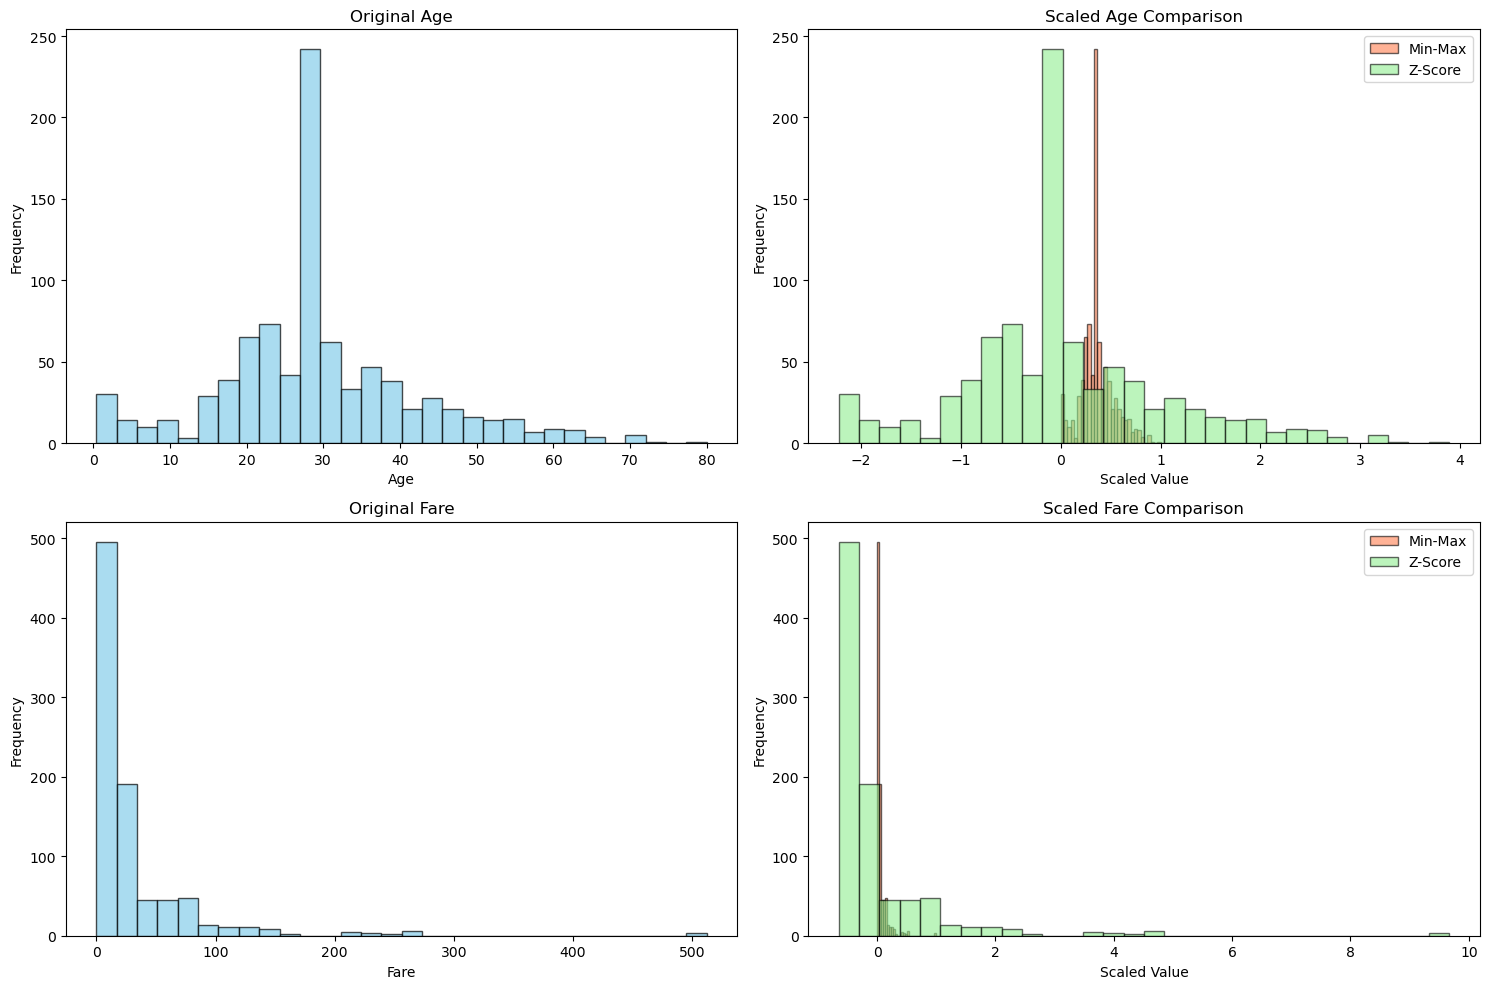

In [12]:
# Visualize the scaling comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

features_to_plot = ['Age', 'Fare']

for idx, feature in enumerate(features_to_plot):
    # Original data
    axes[idx, 0].hist(df_numeric[feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Original {feature}')
    axes[idx, 0].set_xlabel(feature)
    axes[idx, 0].set_ylabel('Frequency')
    
    # Create comparison of scaled data
    ax2 = axes[idx, 1]
    ax2.hist(df_minmax[f'{feature}_MinMax'], bins=30, color='coral', edgecolor='black', alpha=0.6, label='Min-Max')
    ax2.hist(df_zscore[f'{feature}_ZScore'], bins=30, color='lightgreen', edgecolor='black', alpha=0.6, label='Z-Score')
    ax2.set_title(f'Scaled {feature} Comparison')
    ax2.set_xlabel('Scaled Value')
    ax2.set_ylabel('Frequency')
    ax2.legend()

plt.tight_layout()
plt.show()

## 5. Similarity and Dissimilarity Measures

### 5.1 Pearson's Correlation

In [13]:
# Pearson's Correlation - measures linear relationship between variables
# Range: -1 (perfect negative correlation) to +1 (perfect positive correlation)

# Select numerical columns for correlation
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Survived', 'Pclass']
df_corr = df_clean[numerical_cols].copy()

# Calculate Pearson correlation matrix
pearson_corr = df_corr.corr(method='pearson')

print("Pearson's Correlation Matrix:")
print(pearson_corr)
print("\n" + "="*50)

Pearson's Correlation Matrix:
               Age      Fare     SibSp     Parch  Survived    Pclass
Age       1.000000  0.096688 -0.233296 -0.172482 -0.064910 -0.339898
Fare      0.096688  1.000000  0.159651  0.216225  0.257307 -0.549500
SibSp    -0.233296  0.159651  1.000000  0.414838 -0.035322  0.083081
Parch    -0.172482  0.216225  0.414838  1.000000  0.081629  0.018443
Survived -0.064910  0.257307 -0.035322  0.081629  1.000000 -0.338481
Pclass   -0.339898 -0.549500  0.083081  0.018443 -0.338481  1.000000



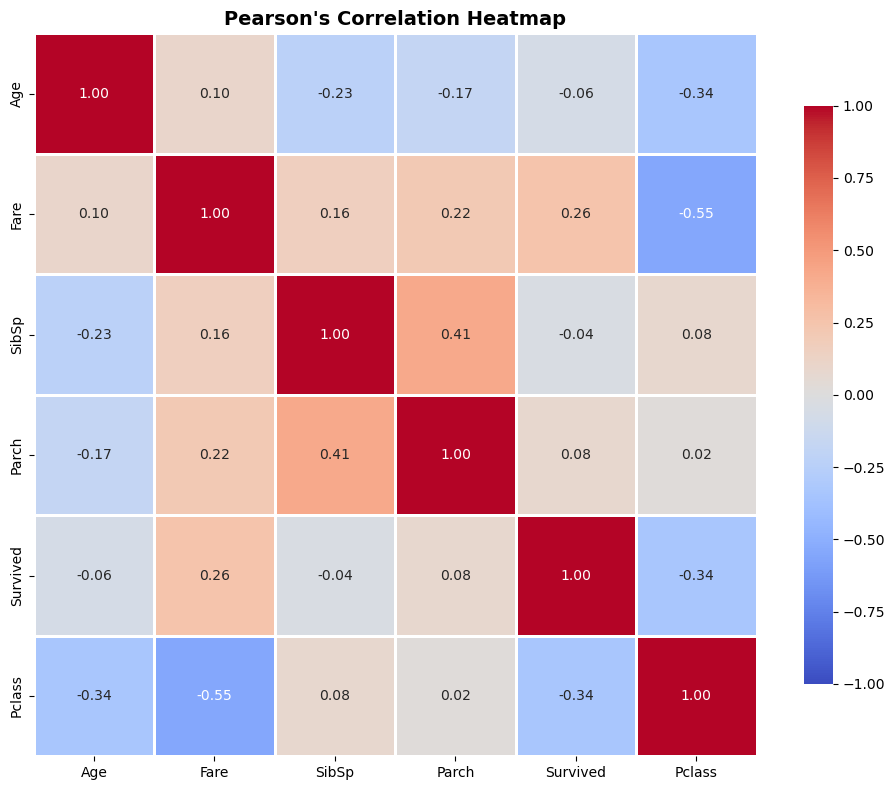


Key Observations:
- Fare and Pclass have strong negative correlation (-0.55)
- Age and Pclass have moderate positive correlation
- Survived has negative correlation with Pclass (higher class = better survival)


In [14]:
# Visualize Pearson's Correlation with heatmap
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.2f', vmin=-1, vmax=1)
plt.title("Pearson's Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretation
print("\nKey Observations:")
print("- Fare and Pclass have strong negative correlation (-0.55)")
print("- Age and Pclass have moderate positive correlation")
print("- Survived has negative correlation with Pclass (higher class = better survival)")

### 5.2 Cosine Similarity

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# Cosine Similarity - measures the cosine of angle between two vectors
# Range: -1 to +1, but typically 0 to 1 for positive data
# 1 = identical orientation, 0 = orthogonal, -1 = opposite

# Select first 10 passengers for demonstration
sample_data = df_clean[numerical_cols].iloc[:10].values

# Calculate cosine similarity matrix
cosine_sim = cosine_similarity(sample_data)

print("Cosine Similarity Matrix (First 10 passengers):")
cosine_sim_df = pd.DataFrame(
    cosine_sim, 
    index=[f'P{i+1}' for i in range(10)],
    columns=[f'P{i+1}' for i in range(10)]
)
print(cosine_sim_df)
print("\n" + "="*50)

Cosine Similarity Matrix (First 10 passengers):
           P1        P2        P3        P4        P5        P6        P7  \
P1   1.000000  0.718285  0.997991  0.779211  0.993853  0.998424  0.895149   
P2   0.718285  1.000000  0.704176  0.995664  0.654848  0.702920  0.950403   
P3   0.997991  0.704176  1.000000  0.766722  0.996569  0.999299  0.887273   
P4   0.779211  0.995664  0.766722  1.000000  0.722015  0.765582  0.975040   
P5   0.993853  0.654848  0.996569  0.722015  1.000000  0.997578  0.856207   
P6   0.998424  0.702920  0.999299  0.765582  0.997578  1.000000  0.887367   
P7   0.895149  0.950403  0.887273  0.975040  0.856207  0.887367  1.000000   
P8   0.413206  0.907204  0.385528  0.869096  0.319222  0.382776  0.743947   
P9   0.993251  0.766543  0.993194  0.822194  0.983501  0.992403  0.924566   
P10  0.685474  0.997088  0.669464  0.988047  0.615742  0.667051  0.930565   

           P8        P9       P10  
P1   0.413206  0.993251  0.685474  
P2   0.907204  0.766543  0.99708

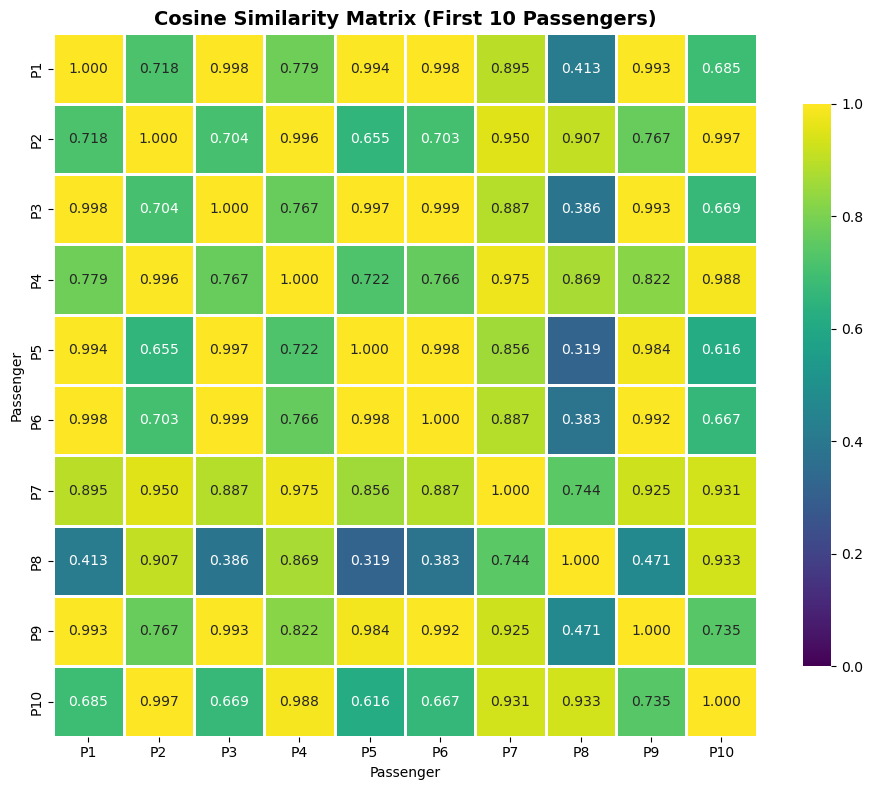


Interpretation:
- Diagonal values are 1.0 (each passenger is identical to themselves)
- Higher values indicate passengers with similar feature patterns
- Lower values indicate passengers with different feature patterns


In [16]:
# Visualize Cosine Similarity
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim_df, annot=True, cmap='viridis', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=0, vmax=1)
plt.title("Cosine Similarity Matrix (First 10 Passengers)", fontsize=14, fontweight='bold')
plt.xlabel("Passenger")
plt.ylabel("Passenger")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Diagonal values are 1.0 (each passenger is identical to themselves)")
print("- Higher values indicate passengers with similar feature patterns")
print("- Lower values indicate passengers with different feature patterns")

### 5.3 Jaccard Similarity

In [17]:
from sklearn.metrics import jaccard_score

# Jaccard Similarity - measures similarity between sets
# Jaccard = |A ∩ B| / |A ∪ B|
# Range: 0 (no similarity) to 1 (identical sets)
# Best used for binary or categorical data

# Create binary features for Jaccard similarity
# Convert Pclass to binary indicators
df_binary = df_clean[['Pclass', 'Sex', 'Survived', 'Embarked']].copy()
df_binary['Pclass_1'] = (df_clean['Pclass'] == 1).astype(int)
df_binary['Pclass_2'] = (df_clean['Pclass'] == 2).astype(int)
df_binary['Pclass_3'] = (df_clean['Pclass'] == 3).astype(int)
df_binary['Sex_Male'] = (df_clean['Sex'] == 'male').astype(int)
df_binary['Embarked_S'] = (df_clean['Embarked'] == 'S').astype(int)
df_binary['Embarked_C'] = (df_clean['Embarked'] == 'C').astype(int)

# Select binary columns
binary_cols = ['Pclass_1', 'Pclass_2', 'Pclass_3', 'Sex_Male', 'Survived', 'Embarked_S', 'Embarked_C']
binary_data = df_binary[binary_cols].iloc[:10].values

# Calculate Jaccard similarity manually
def jaccard_similarity_manual(vec1, vec2):
    intersection = np.sum(np.logical_and(vec1, vec2))
    union = np.sum(np.logical_or(vec1, vec2))
    if union == 0:
        return 0
    return intersection / union

# Calculate Jaccard similarity matrix
n_samples = len(binary_data)
jaccard_matrix = np.zeros((n_samples, n_samples))

for i in range(n_samples):
    for j in range(n_samples):
        jaccard_matrix[i, j] = jaccard_similarity_manual(binary_data[i], binary_data[j])

jaccard_df = pd.DataFrame(
    jaccard_matrix,
    index=[f'P{i+1}' for i in range(n_samples)],
    columns=[f'P{i+1}' for i in range(n_samples)]
)

print("Jaccard Similarity Matrix (First 10 passengers, Binary features):")
print(jaccard_df)
print("\n" + "="*50)

Jaccard Similarity Matrix (First 10 passengers, Binary features):
           P1   P2    P3   P4        P5        P6    P7        P8    P9  P10
P1   1.000000  0.0  0.50  0.2  1.000000  0.666667  0.50  1.000000  0.50  0.0
P2   0.000000  1.0  0.20  0.5  0.000000  0.000000  0.20  0.000000  0.20  0.5
P3   0.500000  0.2  1.00  0.5  0.500000  0.250000  0.20  0.500000  1.00  0.2
P4   0.200000  0.5  0.50  1.0  0.200000  0.000000  0.50  0.200000  0.50  0.2
P5   1.000000  0.0  0.50  0.2  1.000000  0.666667  0.50  1.000000  0.50  0.0
P6   0.666667  0.0  0.25  0.0  0.666667  1.000000  0.25  0.666667  0.25  0.0
P7   0.500000  0.2  0.20  0.5  0.500000  0.250000  1.00  0.500000  0.20  0.0
P8   1.000000  0.0  0.50  0.2  1.000000  0.666667  0.50  1.000000  0.50  0.0
P9   0.500000  0.2  1.00  0.5  0.500000  0.250000  0.20  0.500000  1.00  0.2
P10  0.000000  0.5  0.20  0.2  0.000000  0.000000  0.00  0.000000  0.20  1.0



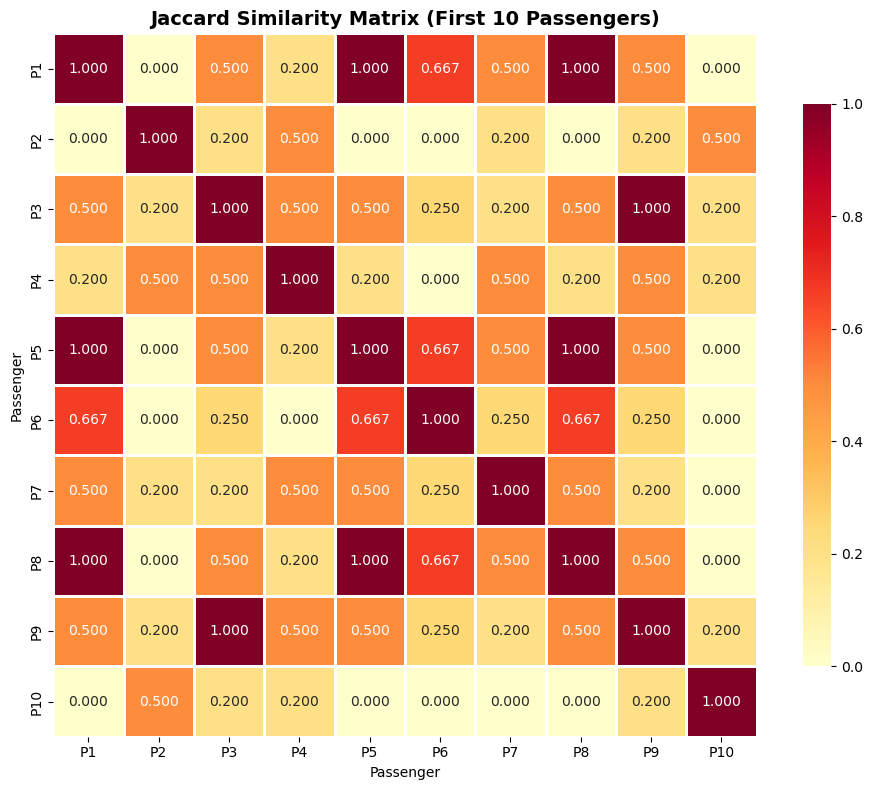


Interpretation:
- Jaccard similarity measures overlap of binary features
- 1.0 = passengers share all the same binary attributes
- 0.0 = passengers share no common binary attributes
- Useful for comparing categorical/binary data patterns


In [18]:
# Visualize Jaccard Similarity
plt.figure(figsize=(10, 8))
sns.heatmap(jaccard_df, annot=True, cmap='YlOrRd', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=0, vmax=1)
plt.title("Jaccard Similarity Matrix (First 10 Passengers)", fontsize=14, fontweight='bold')
plt.xlabel("Passenger")
plt.ylabel("Passenger")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Jaccard similarity measures overlap of binary features")
print("- 1.0 = passengers share all the same binary attributes")
print("- 0.0 = passengers share no common binary attributes")
print("- Useful for comparing categorical/binary data patterns")

### 5.4 Euclidean Distance

In [19]:
from sklearn.metrics.pairwise import euclidean_distances

# Euclidean Distance - measures straight-line distance between two points
# Formula: sqrt(sum((x_i - y_i)^2))
# Range: 0 to infinity (0 = identical, higher = more different)
# Note: This is a DISSIMILARITY measure (lower is more similar)

# Use scaled data for fair comparison
scaled_sample = df_minmax.iloc[:10].values

# Calculate Euclidean distance matrix
euclidean_dist = euclidean_distances(scaled_sample)

euclidean_df = pd.DataFrame(
    euclidean_dist,
    index=[f'P{i+1}' for i in range(10)],
    columns=[f'P{i+1}' for i in range(10)]
)

print("Euclidean Distance Matrix (First 10 passengers, Scaled data):")
print(euclidean_df)
print("\n" + "="*50)

Euclidean Distance Matrix (First 10 passengers, Scaled data):
           P1        P2        P3        P4        P5        P6        P7  \
P1   0.000000  0.236737  0.134734  0.186265  0.205702  0.145997  0.430001   
P2   0.236737  0.000000  0.231639  0.051776  0.179665  0.215529  0.239761   
P3   0.134734  0.231639  0.000000  0.190237  0.113094  0.025153  0.362148   
P4   0.186265  0.051776  0.190237  0.000000  0.152830  0.175940  0.269507   
P5   0.205702  0.179665  0.113094  0.152830  0.000000  0.087965  0.253606   
P6   0.145997  0.215529  0.025153  0.175940  0.087965  0.000000  0.337521   
P7   0.430001  0.239761  0.362148  0.269507  0.253606  0.337521  0.000000   
P8   0.392642  0.551838  0.509916  0.515890  0.583957  0.525121  0.773941   
P9   0.361581  0.399533  0.333629  0.378882  0.348214  0.333611  0.482227   
P10  0.109954  0.312127  0.200578  0.267686  0.295141  0.219895  0.519692   

           P8        P9       P10  
P1   0.392642  0.361581  0.109954  
P2   0.551838  0.3

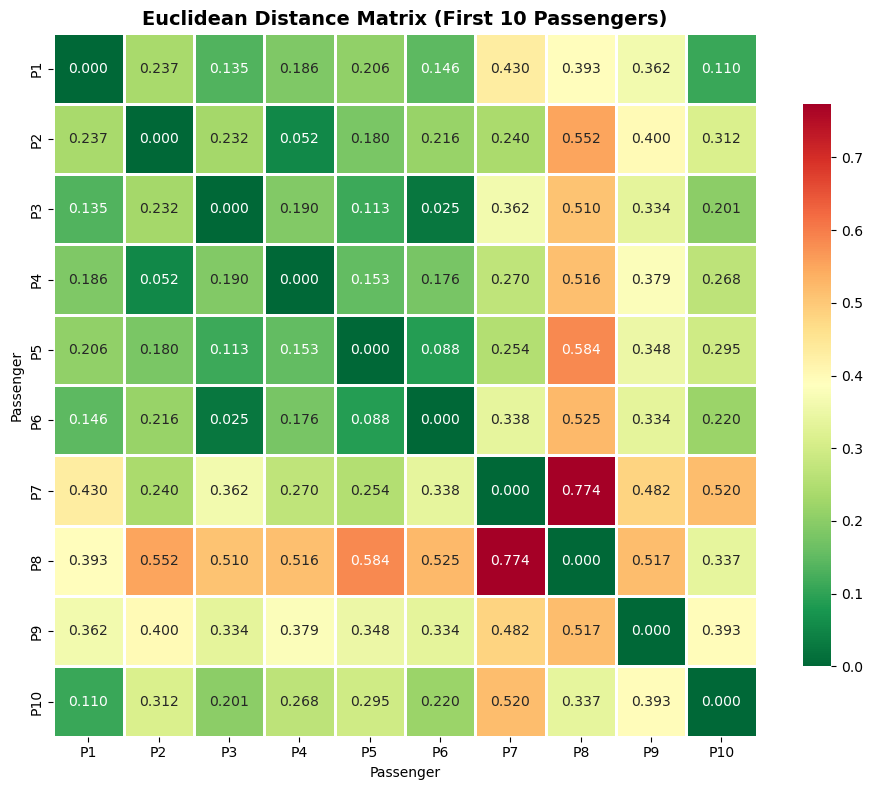


Interpretation:
- Diagonal values are 0.0 (distance from a point to itself)
- Lower values = more similar passengers (closer in feature space)
- Higher values = more different passengers (farther in feature space)
- This is a DISSIMILARITY measure (opposite of similarity)


In [20]:
# Visualize Euclidean Distance
plt.figure(figsize=(10, 8))
sns.heatmap(euclidean_df, annot=True, cmap='RdYlGn_r',  # Reversed colormap: green=close, red=far
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f')
plt.title("Euclidean Distance Matrix (First 10 Passengers)", fontsize=14, fontweight='bold')
plt.xlabel("Passenger")
plt.ylabel("Passenger")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Diagonal values are 0.0 (distance from a point to itself)")
print("- Lower values = more similar passengers (closer in feature space)")
print("- Higher values = more different passengers (farther in feature space)")
print("- This is a DISSIMILARITY measure (opposite of similarity)")

## 6. Summary Comparison of Similarity Measures

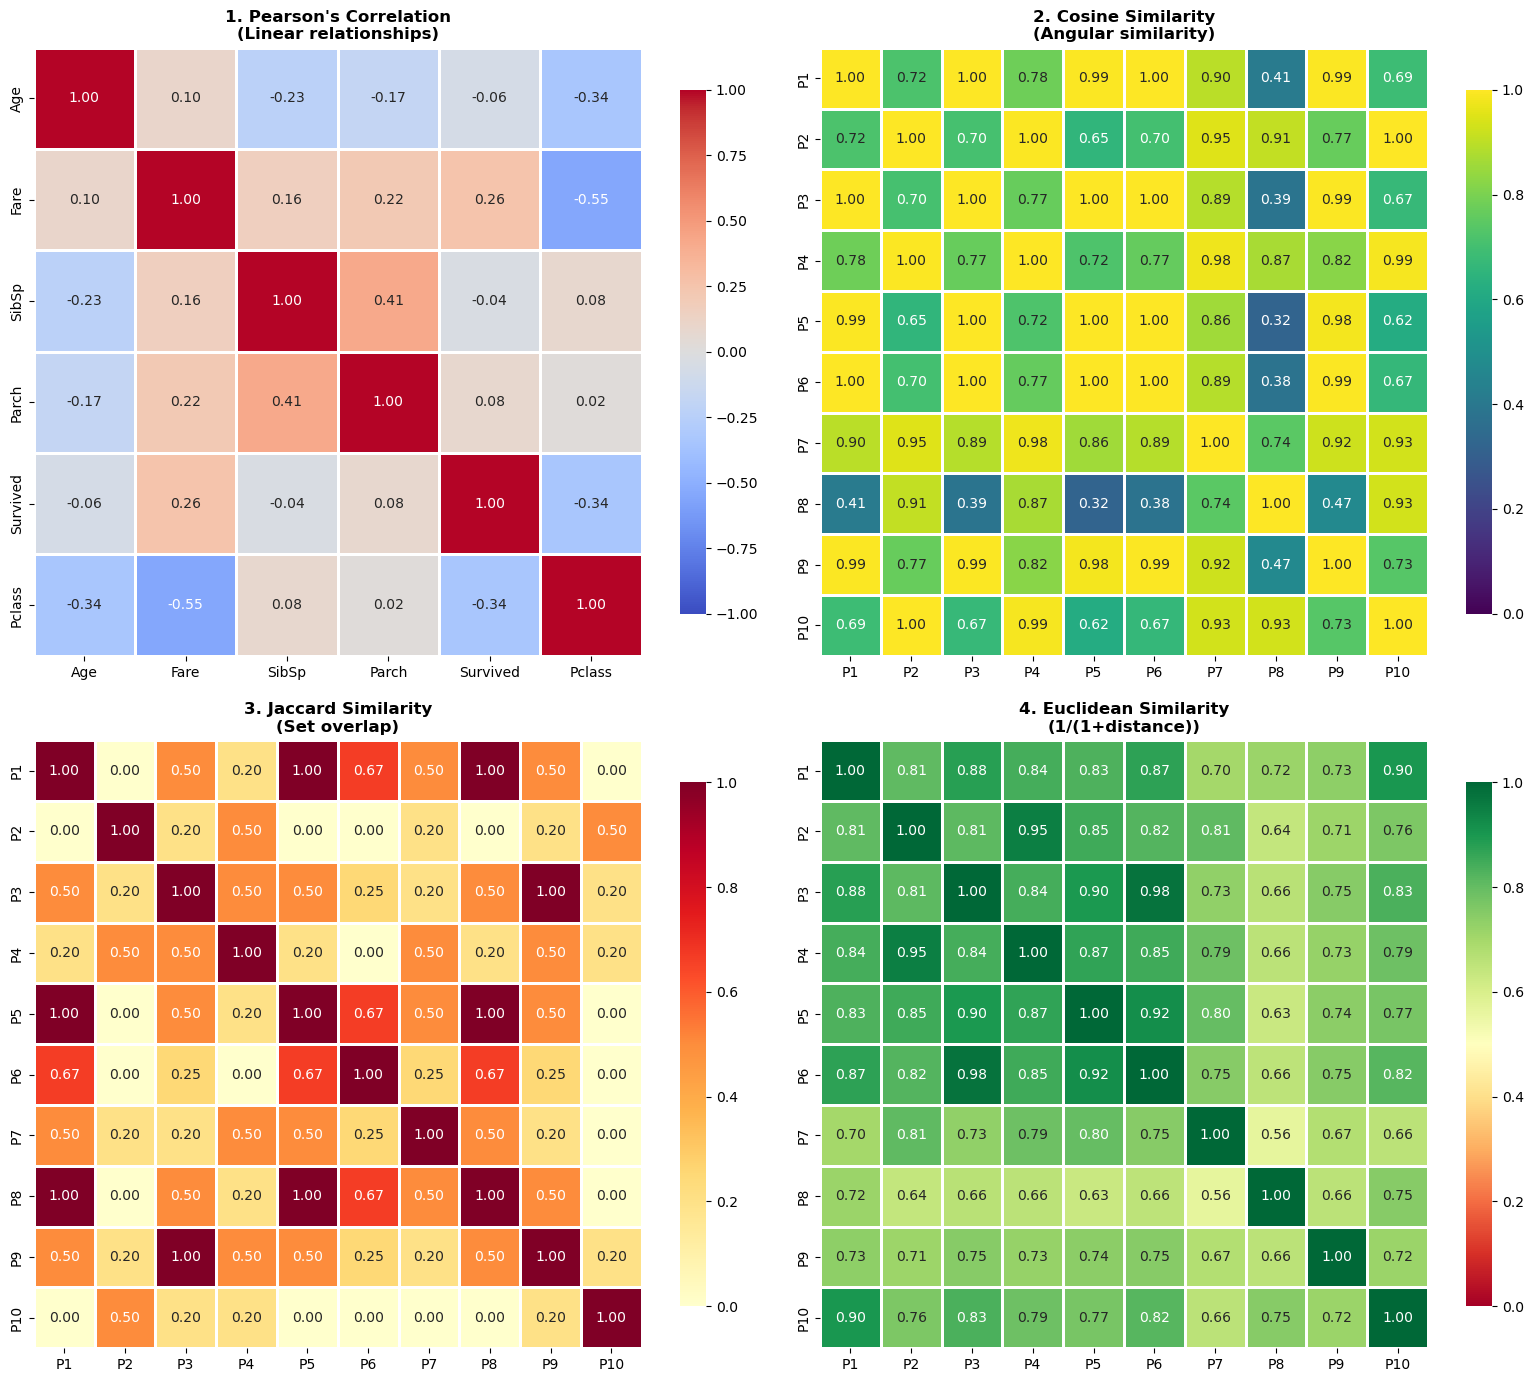

In [21]:
# Create a comprehensive comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Pearson Correlation
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f', vmin=-1, vmax=1,
            ax=axes[0, 0], cbar_kws={"shrink": 0.8})
axes[0, 0].set_title("1. Pearson's Correlation\n(Linear relationships)", fontweight='bold')

# 2. Cosine Similarity
sns.heatmap(cosine_sim_df, annot=True, cmap='viridis', 
            square=True, linewidths=1, fmt='.2f', vmin=0, vmax=1,
            ax=axes[0, 1], cbar_kws={"shrink": 0.8})
axes[0, 1].set_title("2. Cosine Similarity\n(Angular similarity)", fontweight='bold')

# 3. Jaccard Similarity
sns.heatmap(jaccard_df, annot=True, cmap='YlOrRd', 
            square=True, linewidths=1, fmt='.2f', vmin=0, vmax=1,
            ax=axes[1, 0], cbar_kws={"shrink": 0.8})
axes[1, 0].set_title("3. Jaccard Similarity\n(Set overlap)", fontweight='bold')

# 4. Euclidean Distance (converted to similarity for comparison)
# Convert distance to similarity: similarity = 1 / (1 + distance)
euclidean_sim = 1 / (1 + euclidean_df)
sns.heatmap(euclidean_sim, annot=True, cmap='RdYlGn',
            square=True, linewidths=1, fmt='.2f', vmin=0, vmax=1,
            ax=axes[1, 1], cbar_kws={"shrink": 0.8})
axes[1, 1].set_title("4. Euclidean Similarity\n(1/(1+distance))", fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# Summary table of similarity measures
summary_data = {
    'Measure': ['Pearson Correlation', 'Cosine Similarity', 'Jaccard Similarity', 'Euclidean Distance'],
    'Type': ['Similarity', 'Similarity', 'Similarity', 'Dissimilarity'],
    'Range': ['-1 to +1', '0 to 1', '0 to 1', '0 to ∞'],
    'Best For': [
        'Linear relationships',
        'Direction/orientation',
        'Binary/categorical sets',
        'Spatial distance'
    ],
    'Interpretation': [
        '+1=perfect positive, 0=no linear relation, -1=perfect negative',
        '1=same direction, 0=orthogonal',
        '1=identical sets, 0=no overlap',
        '0=identical, higher=more different'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY OF SIMILARITY AND DISSIMILARITY MEASURES")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


SUMMARY OF SIMILARITY AND DISSIMILARITY MEASURES
            Measure          Type    Range                Best For                                                 Interpretation
Pearson Correlation    Similarity -1 to +1    Linear relationships +1=perfect positive, 0=no linear relation, -1=perfect negative
  Cosine Similarity    Similarity   0 to 1   Direction/orientation                                 1=same direction, 0=orthogonal
 Jaccard Similarity    Similarity   0 to 1 Binary/categorical sets                                 1=identical sets, 0=no overlap
 Euclidean Distance Dissimilarity   0 to ∞        Spatial distance                             0=identical, higher=more different
